### Architecture 
In this experiment, FiLM is applied at an late stage which is last stage 8 accessible from timm, so FiLM is applied after stage 8,
Stem (Stage 1): conv_stem → bn1 → act1

MBConv stages 2–8: stored in blocks[0]..blocks[6]

blocks[0] → Stage 2 

blocks[1] → Stage 3

blocks[2] → Stage 4

blocks[3] → Stage 5

blocks[4] → Stage 6

blocks[5] → Stage 7

blocks[6] → Stage 8 ->FiLM(Late Modulation)

Head (Stage 9): conv_head → bn2 → global_pool → MLP

<br>
<br>

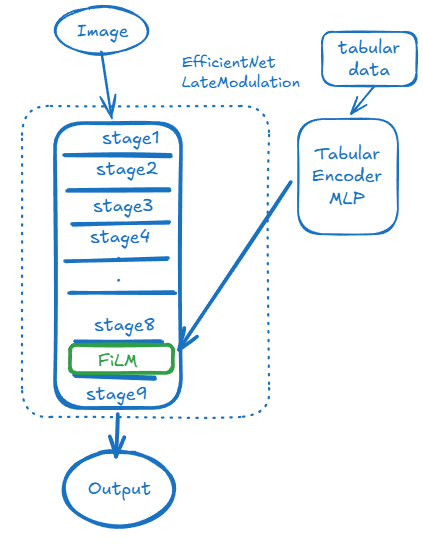



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_late_modulation_finetune_tab_encoder_big")   #

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_late_modulation_finetune_tab_encoder_big"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=6,                   # to update the backbone block at late stage on index 6 (last MBCblock of EfficientNet)
    apply_to_all_after=False,            # False: to not apply FiLM on multiple blocks, just single block with the index passed
    use_bn_affine=False,                # False: to not use learnable affine parameter of Batch Normalization instead use FiLM generated affine parameters(gamma and beta)
    freeze_backbone=False,              # False: to not freeze backbone, True -> Freeze backbone entirely
    tab_encoder_capacity="big",
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_late_modulation_finetune_tab_encoder_big: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=39.1892 | ValRMSE: 34.5281
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=30.6010 | ValRMSE: 45.2614
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=24.2936 | ValRMSE: 23.8099
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=19.4247 | ValRMSE: 20.2009
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=16.3826 | ValRMSE: 19.9385
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=14.5607 | ValRMSE: 20.4099
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=13.2527 | ValRMSE: 20.4614
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=12.2258 | ValRMSE: 20.9330
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=11.5587 | ValRMSE: 20.7362
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=11.3951 | ValRMSE: 20.7169
Early stopping at epoch 10
Fold 1 best RMSE: 19.9385

=== exp12_film_fusion_effB1_internal_late_modulation_finetune_tab_encoder_big: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=39.1278 | ValRMSE: 33.3422
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 19.9385 (n=1983)
Fold 2 OOF RMSE: 20.2900 (n=1983)
Fold 3 OOF RMSE: 19.8216 (n=1982)
Fold 4 OOF RMSE: 19.4085 (n=1982)
Fold 5 OOF RMSE: 20.4576 (n=1982)


### Train and Validation RMSE Curve

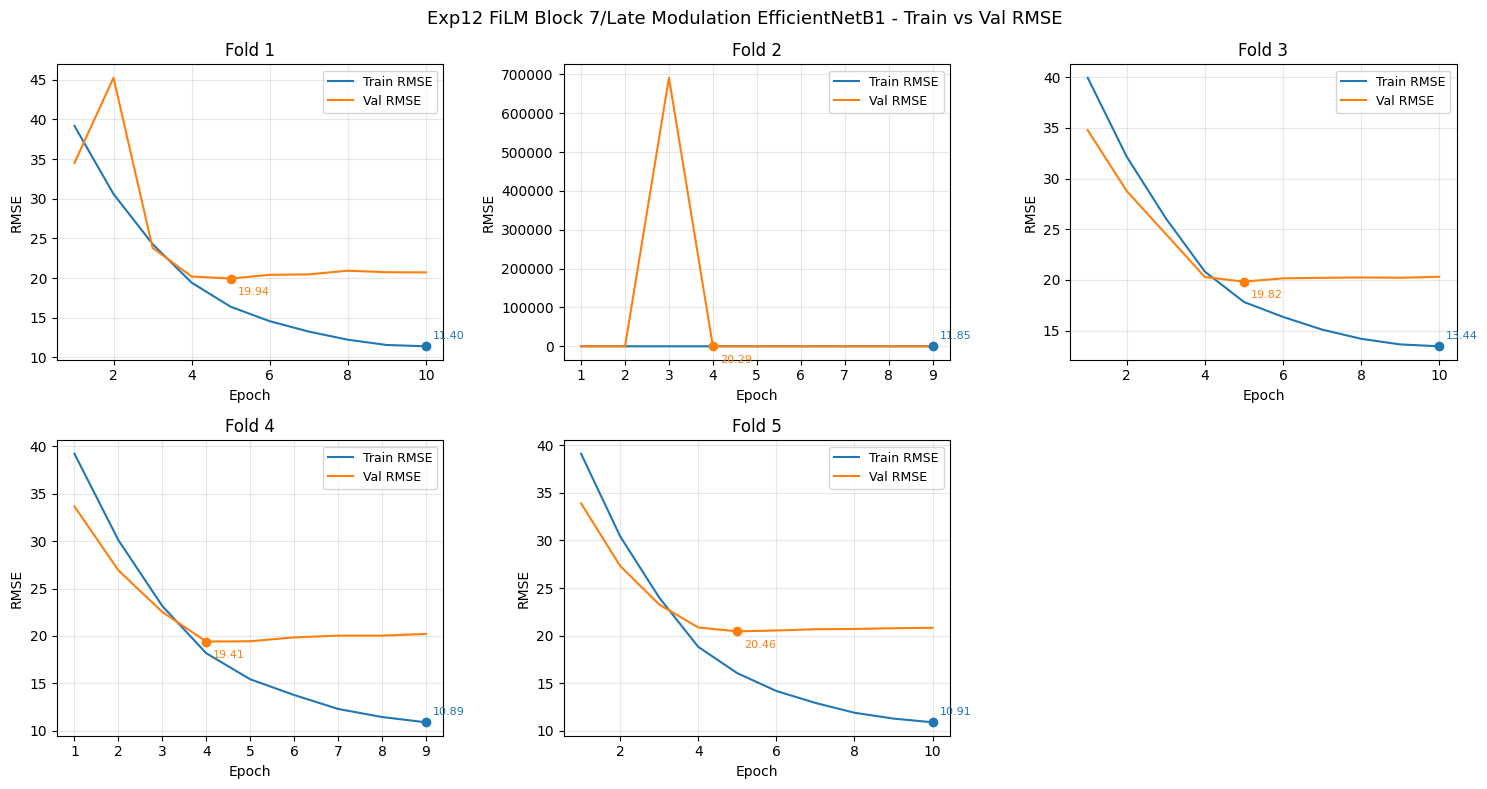

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM Block 7/Late Modulation EfficientNetB1")

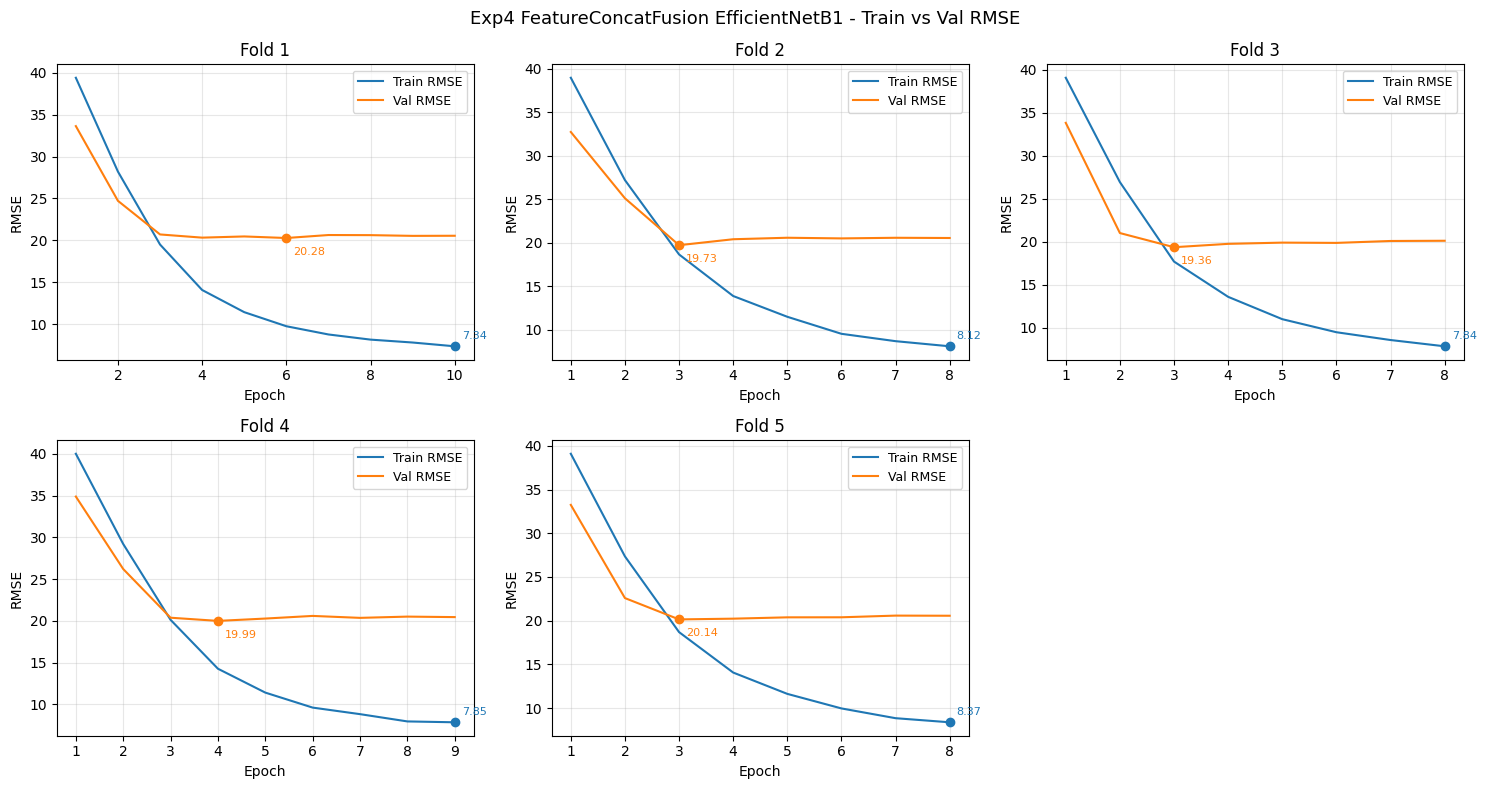

In [12]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

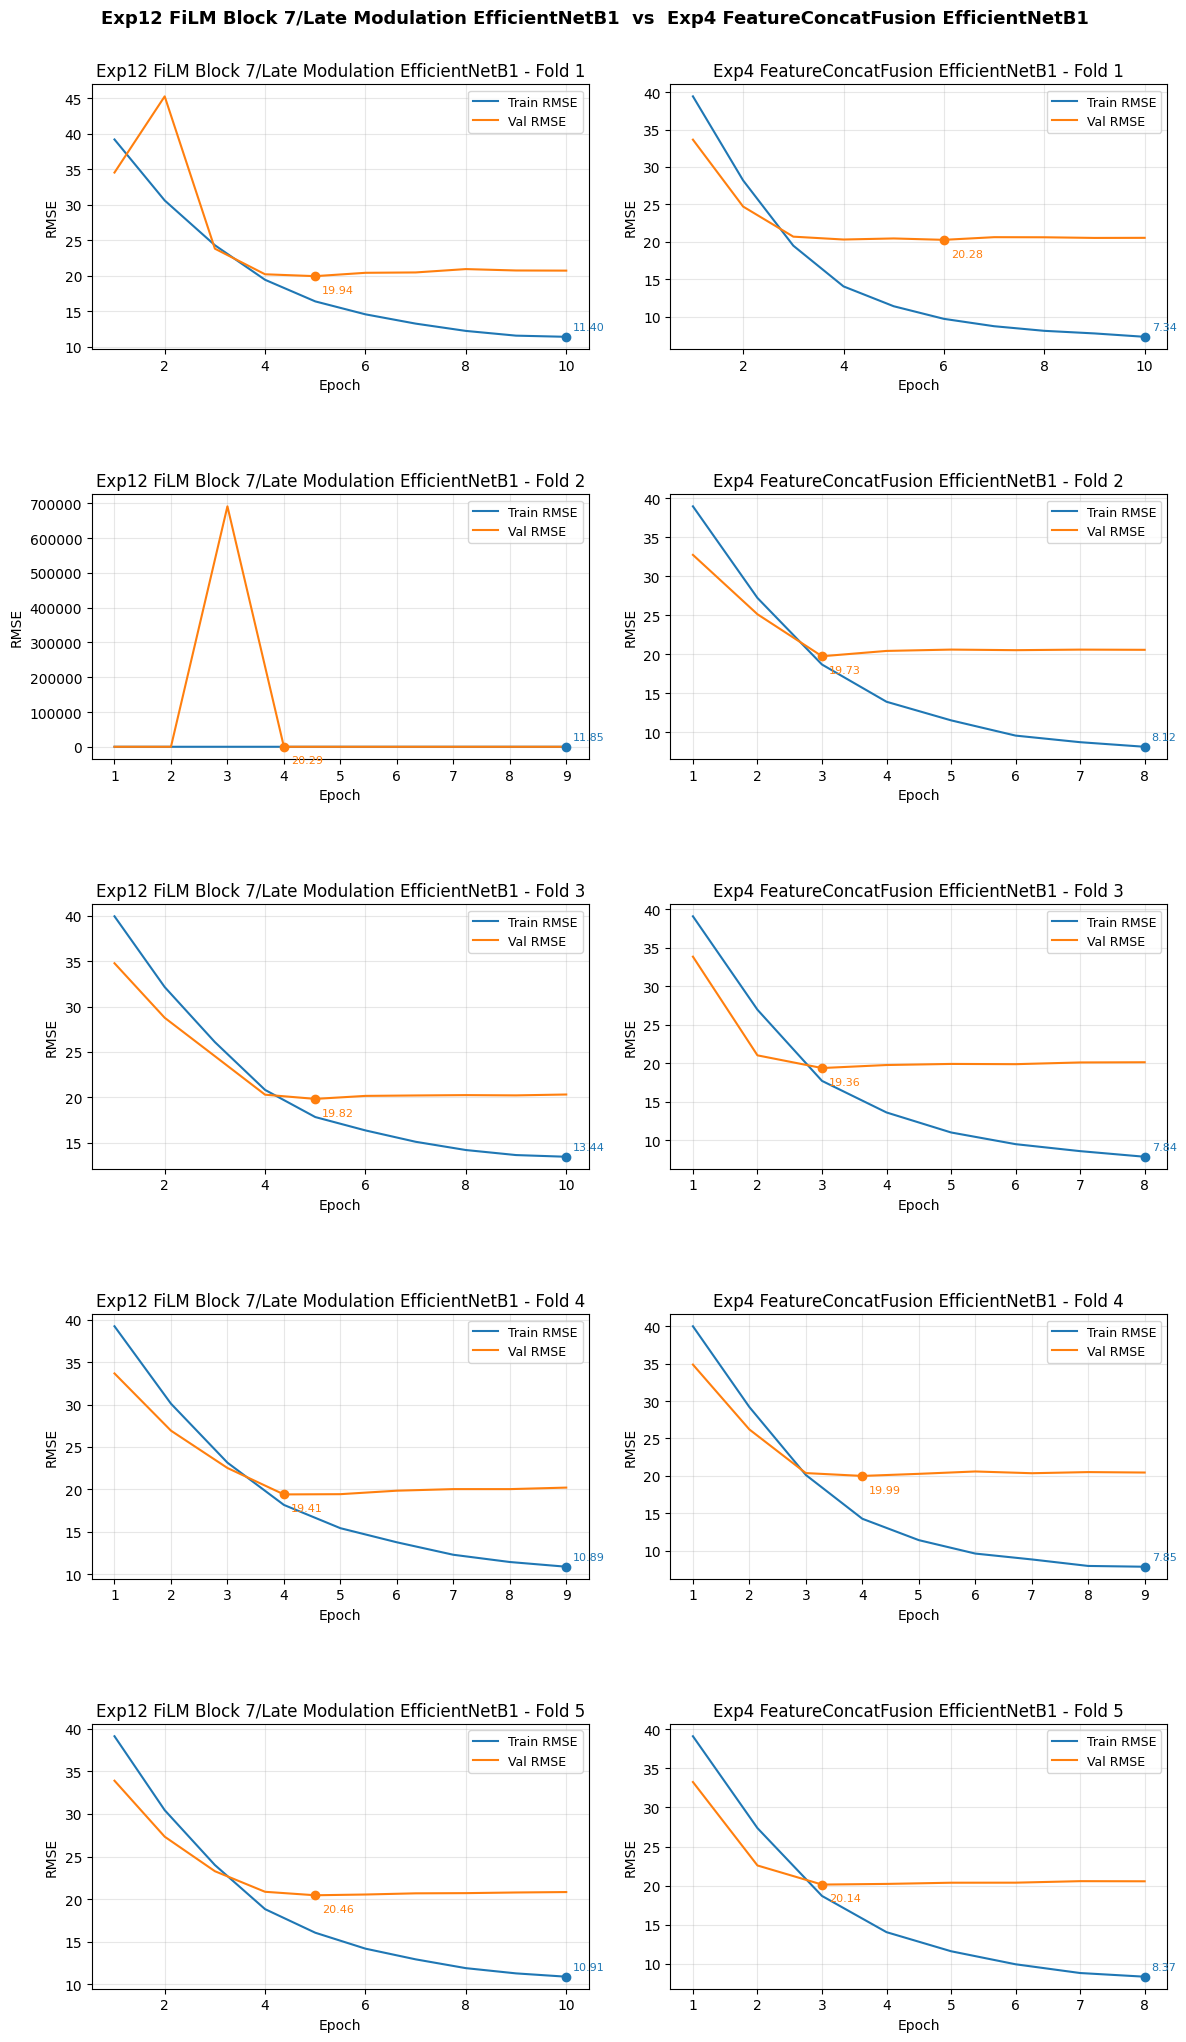

In [13]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM Block 7/Late Modulation EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [14]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,76769dbee1699e04ae1befa3128db7d6,2,100,7.923828,92.076172
1,4c1e05895368c997fdd709bbd1ac3dae,2,2,92.871674,90.871674
2,e5a84da44afc0abddfbb36907a5ee845,5,100,10.215342,89.784658
3,3d69187b44aba9adbd7fd5f0d3554cd1,5,7,96.028442,89.028442
4,9fdfa0708e98d8320e0b526315bb264a,5,7,94.625412,87.625412


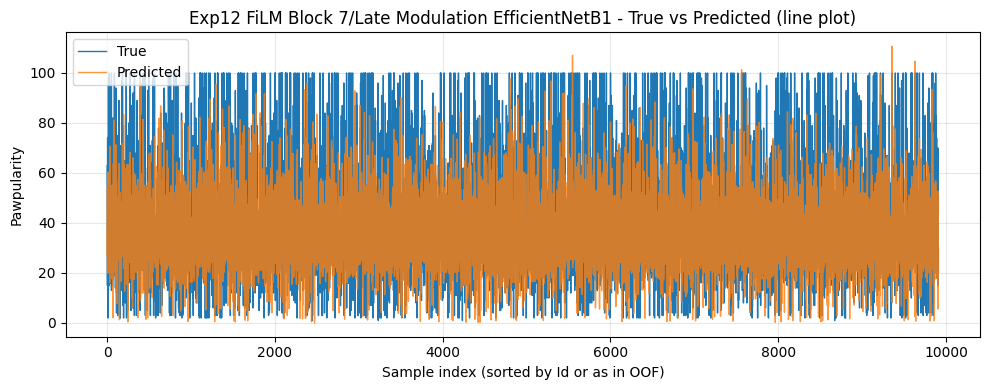

In [15]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM Block 7/Late Modulation EfficientNetB1")





Exp12 FiLM Block 7/Late Modulation EfficientNetB1 OOF RMSE: 19.986675152606253
Exp4_FeatureConcat EffB1 Fusion OOF RMSE: 19.90331621767278
ΔRMSE (Exp4_FeatureConcat EffB1 Fusion - Exp12 FiLM Block 7/Late Modulation EfficientNetB1): -0.08335893493347157


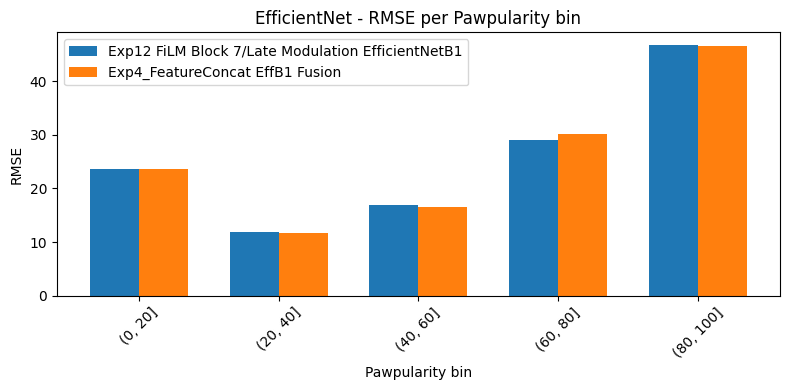

In [16]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12 FiLM Block 7/Late Modulation EfficientNetB1",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

In [17]:
df_bins.head()

,bin,count,Exp12 FiLM Block 7/Late Modulation EfficientNetB1_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,23.612468,23.561754,-0.050714,Exp4_FeatureConcat EffB1 Fusion_better
1,"(20, 40]",5119,11.949643,11.605182,-0.344461,Exp4_FeatureConcat EffB1 Fusion_better
2,"(40, 60]",2088,16.965543,16.538259,-0.427283,Exp4_FeatureConcat EffB1 Fusion_better
3,"(60, 80]",727,28.980559,30.127592,1.147033,Exp12 FiLM Block 7/Late Modulation EfficientNe...
4,"(80, 100]",561,46.765890,46.623998,-0.141892,Exp4_FeatureConcat EffB1 Fusion_better


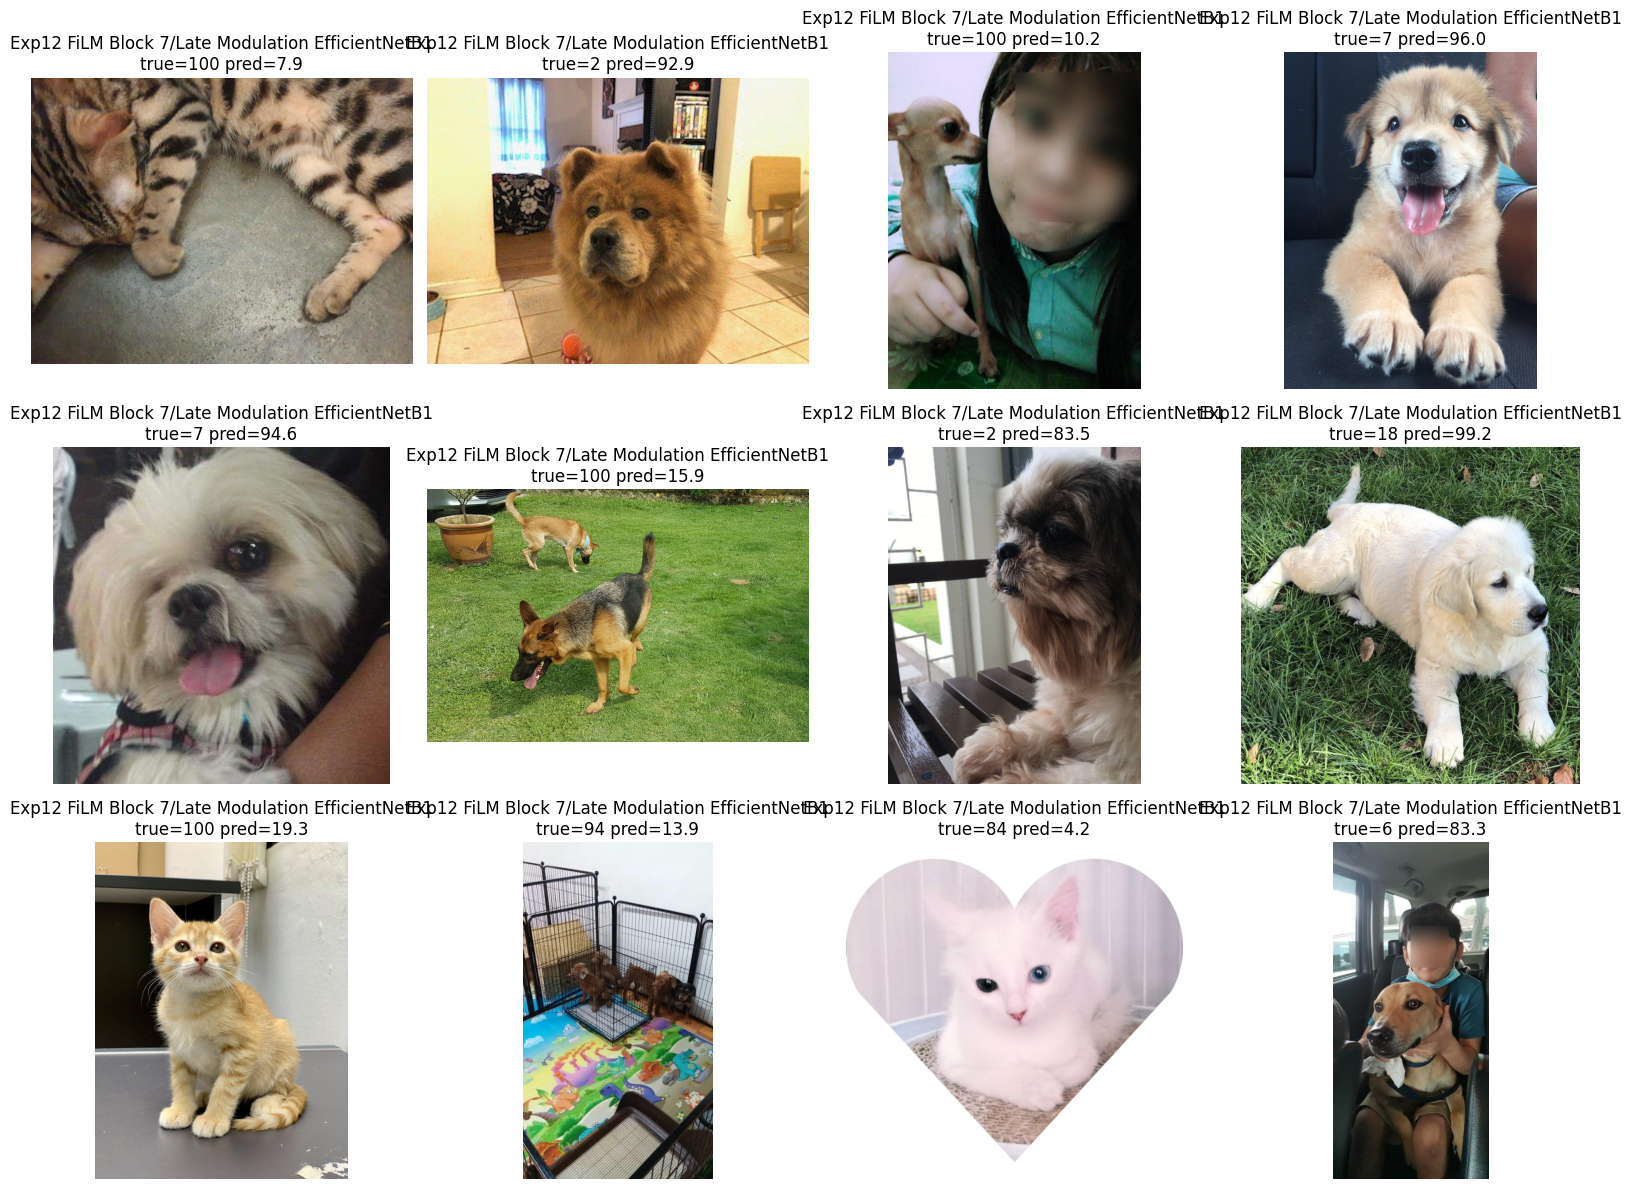

In [18]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12 FiLM Block 7/Late Modulation EfficientNetB1")

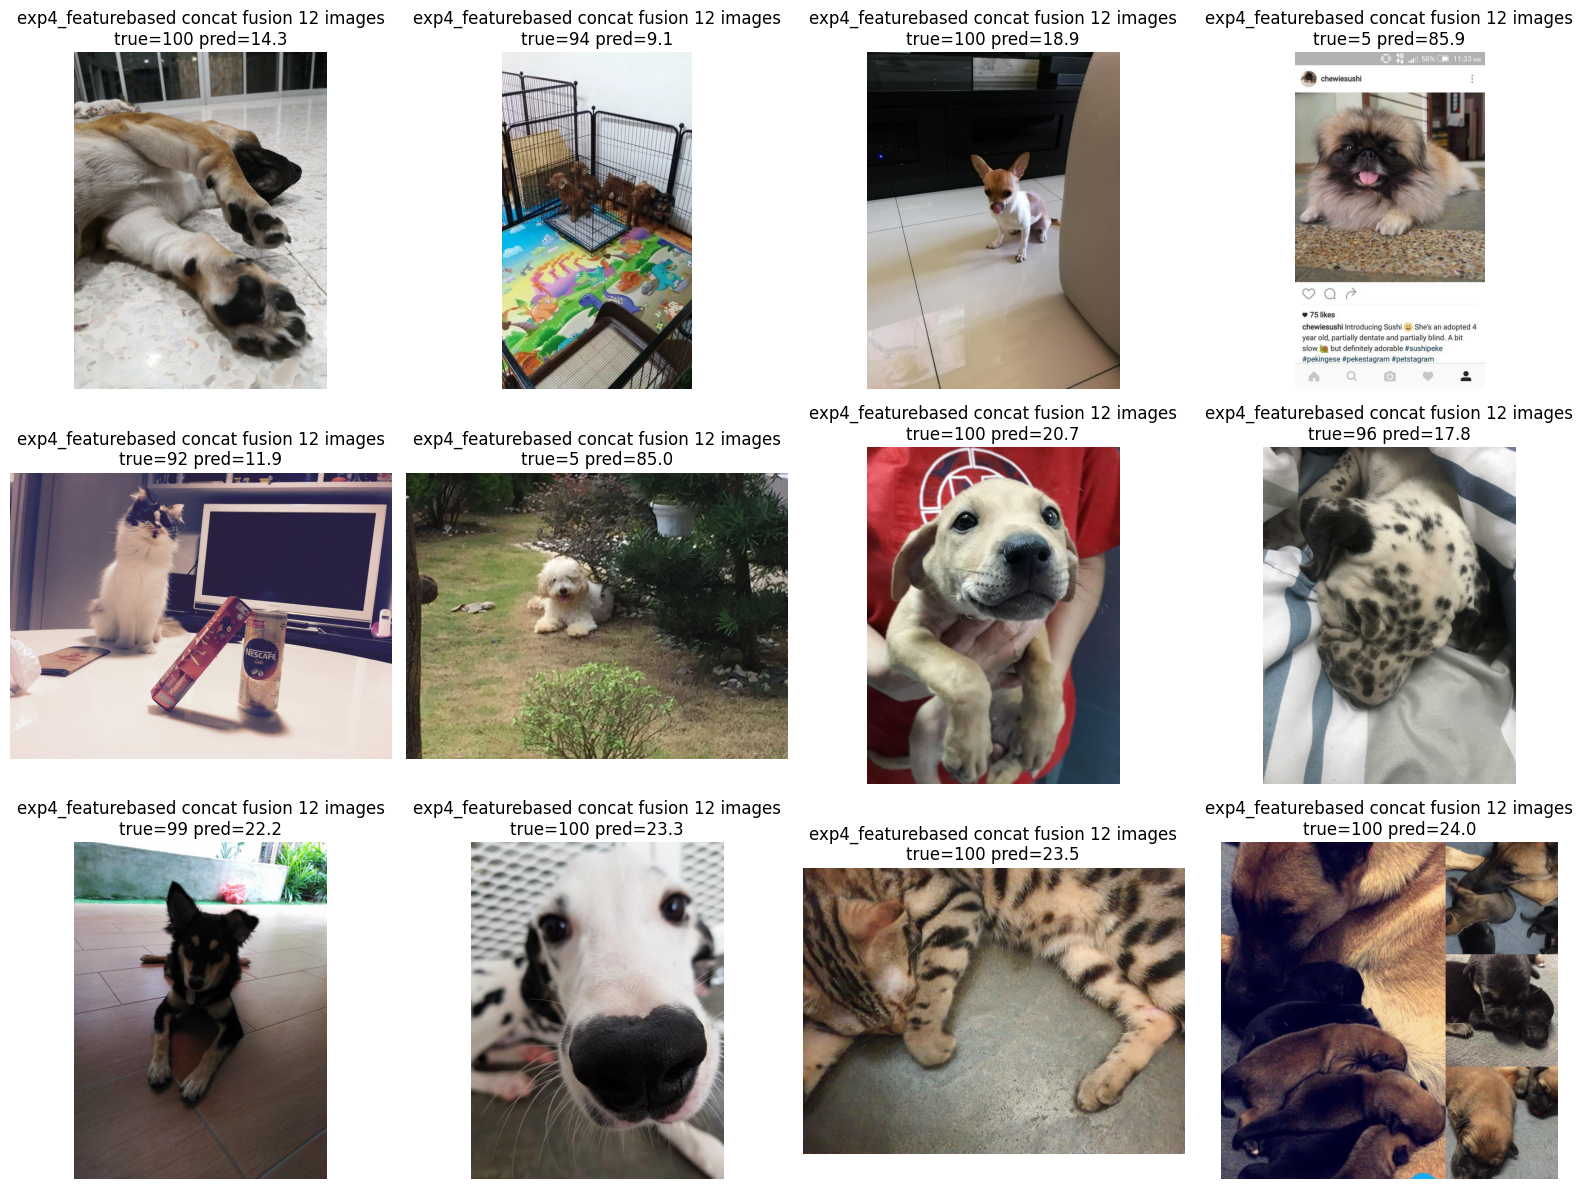

In [19]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")